圖片已成功儲存為 confusion_matrix_updated.png


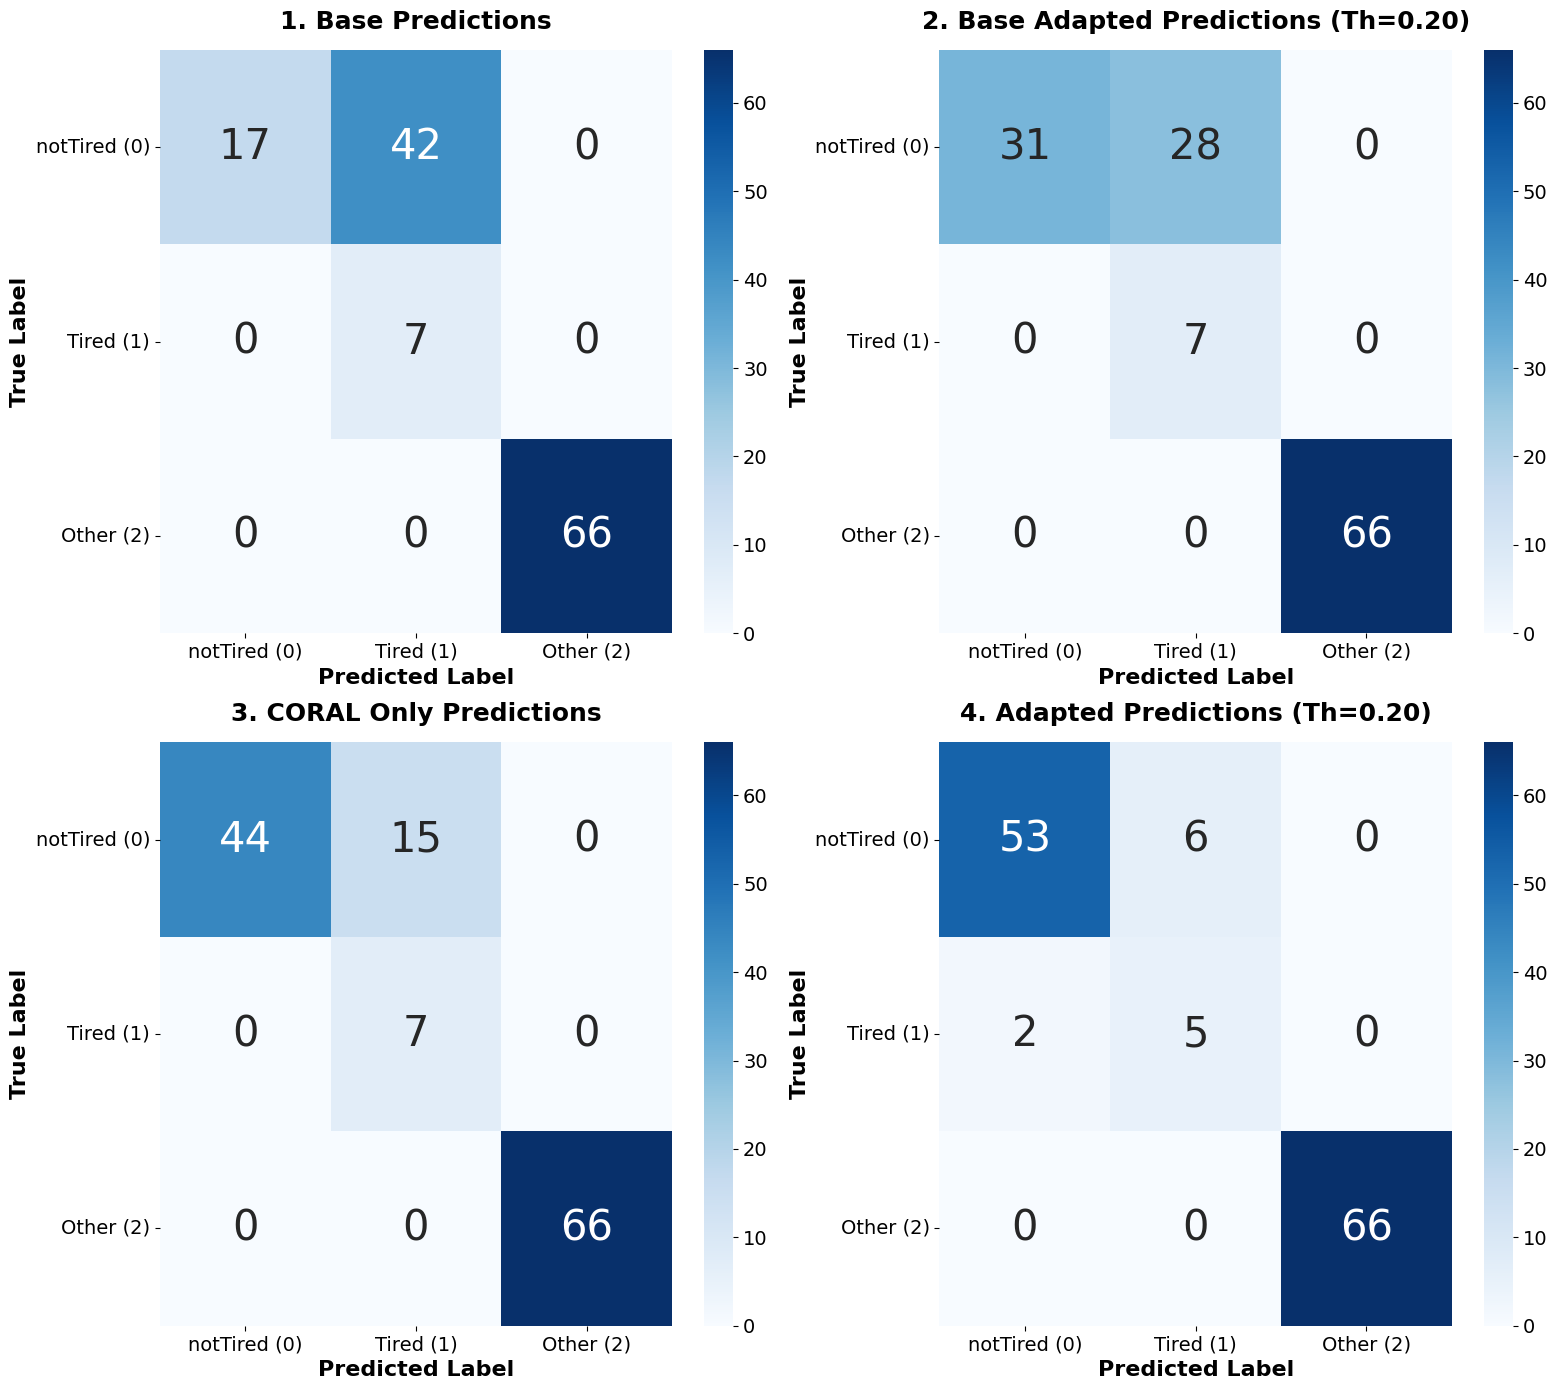

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. 定義四個混淆矩陣的數據
data_1 = np.array([[17, 42, 0], [0, 7, 0], [0, 0, 66]])

data_2 = np.array([[31, 28, 0], [0, 7, 0], [0, 0, 66]])

data_3 = np.array([[44, 15, 0], [0, 7, 0], [0, 0, 66]])

data_4 = np.array([[53, 6, 0], [2, 5, 0], [0, 0, 66]])

matrices = [data_1, data_2, data_3, data_4]

# 定義標題與標籤
titles = [
    "1. Base Predictions",
    "2. Base Adapted Predictions (Th=0.20)",
    "3. CORAL Only Predictions",
    "4. Adapted Predictions (Th=0.20)",
]
labels = ["notTired (0)", "Tired (1)", "Other (2)"]

# ==========================================
# 2. 字體大小設定區
# ==========================================
TITLE_SIZE = 18  # 每張圖的標題大小
LABEL_SIZE = 16  # "True Label" 和 "Predicted Label" 的字體大小
TICK_SIZE = 14  # 座標軸刻度的字體大小
ANNOT_SIZE = 30  # 矩陣內部數字的大小
# ==========================================

# 3. 開始繪圖 (2x2 佈局)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i in range(4):
    ax = axes[i]

    # 繪製熱圖 (Heatmap)
    sns.heatmap(
        matrices[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=66,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        annot_kws={"size": ANNOT_SIZE},  # 【修改處】移除了 "weight": "bold"，讓數字恢復常規字體
        cbar=True,
    )

    # 設定標題、X軸與Y軸標籤
    ax.set_title(titles[i], fontsize=TITLE_SIZE, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted Label", fontsize=LABEL_SIZE, fontweight="bold")
    ax.set_ylabel("True Label", fontsize=LABEL_SIZE, fontweight="bold")

    # 設定字體大小與旋轉角度
    ax.tick_params(axis="x", labelsize=TICK_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE, labelrotation=0)

    # 調整右側顏色條 (Colorbar) 的刻度字體大小
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=TICK_SIZE)

# 4. 自動調整佈局
plt.tight_layout()

# ==========================================
# 5. 儲存圖片並顯示
# ==========================================
# dpi=300 可確保圖片高解析度，bbox_inches='tight' 可防文字被裁切
output_filename = "confusion_matrix_updated.png"
plt.savefig(output_filename, dpi=300, bbox_inches="tight")
print(f"圖片已成功儲存為 {output_filename}")

plt.show()